In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (LinearRegression,LogisticRegression,Ridge)
from sklearn.metrics import(mean_squared_error,r2_score,confusion_matrix,classification_report,roc_curve,roc_auc_score,precision_score,recall_score,f1_score)
df=pd.read_csv("cleaned_data.csv")
print(df.head())
print("Shape:",df.shape)
print("Whole missing value:",df.isnull().sum().sum())

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Lot Shape Land Contour Utilities  ... Enclosed Porch 3Ssn Porch  \
0       IR1          Lvl    AllPub  ...              0          0   
1       Reg          Lvl    AllPub  ...              0          0   
2       IR1          Lvl    AllPub  ...              0          0   
3       Reg          Lvl    AllPub  ...              0          0   
4       IR1          Lvl    AllPub  ...              0          0   

  Screen Porch Pool Area Misc Val Mo Sold Yr Sold  Sale Type  Sale Condition  \
0            0         0        0       5 

In [3]:
y_reg=df["SalePrice"]
y_clf=(df["SalePrice"] > df["SalePrice"].median()).astype(int)
X=df.drop(columns=["SalePrice"])
print("Feature shape:",X.shape)
print("Regression target shape:",y_reg.shape)
print("Classification target shape:",y_clf.shape)
print("class distribution:",y_clf.value_counts())

Feature shape: (2930, 75)
Regression target shape: (2930,)
Classification target shape: (2930,)
class distribution: SalePrice
0    1467
1    1463
Name: count, dtype: int64


In [4]:
categorical_columns=X.select_dtypes(include=["object","category"]).columns
print("Categorical columns:",categorical_columns)
X=pd.get_dummies(X,columns=categorical_columns,drop_first=True)
print("After encoding shape:",X.shape)

Categorical columns: Index(['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
       'Paved Drive', 'Sale Type', 'Sale Condition'],
      dtype='object')
After encoding shape: (2930, 244)


In [5]:
X_train,X_test,y_reg_train,y_reg_test=train_test_split(X,y_reg,test_size=0.2,random_state=42)
X_train_clf,X_test_clf,y_clf_train,y_clf_test=train_test_split(X,y_clf,test_size=0.2,random_state=42)
print("Training feature:",X_train.shape)
print("Testing feature:",X_test.shape)
print("Training regression target:",y_reg_train.shape)
print("Testing regression target:",y_reg_test.shape)
print("Training classification target:",y_clf_train.shape)
print("Testing classification target:",y_clf_test.shape)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("Training data shape:",X_train_scaled.shape)
print("Testing data shape:",X_test_scaled.shape)

Training feature: (2344, 244)
Testing feature: (586, 244)
Training regression target: (2344,)
Testing regression target: (586,)
Training classification target: (2344,)
Testing classification target: (586,)
Training data shape: (2344, 244)
Testing data shape: (586, 244)


In [6]:
linear_model=LinearRegression()
linear_model.fit(X_train_scaled,y_reg_train)
y_pred_reg=linear_model.predict(X_test_scaled)
mse=mean_squared_error(y_reg_test,y_pred_reg)
r2=r2_score(y_reg_test,y_pred_reg)
print("Mean Squared Error:",mse)
print("R2 Score:", r2)
coefficients=pd.DataFrame({"Feature":X.columns,"Coefficient":linear_model.coef_})
coefficients["Absolute coefficients"]=coefficients["Coefficient"].abs()
coefficients=coefficients.sort_values(by="Absolute coefficients",ascending=False)
print("Top 3 most important features")
display(coefficients.head(3))

ridge_model=Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled,y_reg_train)
ridge_pred=ridge_model.predict(X_test_scaled)
ridge_mse=mean_squared_error(y_reg_test,ridge_pred)
ridge_r2=r2_score(y_reg_test,ridge_pred)
comparison=pd.DataFrame({"Model":["LinearRegression","RidgeRegression"],"MSE":[mse,ridge_mse],"R2":[r2,ridge_r2]})
display(comparison)

Mean Squared Error: 850429170.1984409
R2 Score: 0.8939290195048258
Top 3 most important features


,Feature,Coefficient,Absolute coefficients
10,BsmtFin SF 1,136518.709775,136518.709775
12,Bsmt Unf SF,123532.448613,123532.448613
13,Total Bsmt SF,-116767.733350,116767.733350


,Model,MSE,R2
0,LinearRegression,8.504292e+08,0.893929
1,RidgeRegression,8.430625e+08,0.894848


confusion matrix:
[[260  21]
 [ 21 284]]
classification report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       281
           1       0.93      0.93      0.93       305

    accuracy                           0.93       586
   macro avg       0.93      0.93      0.93       586
weighted avg       0.93      0.93      0.93       586

AUC: 0.9788227057931276


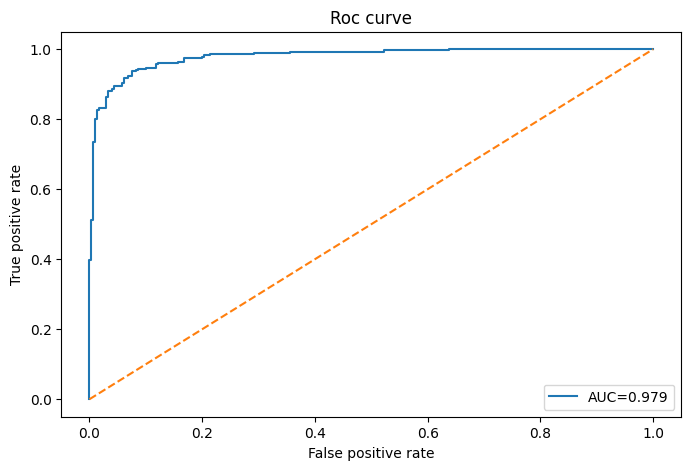

In [7]:
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_clf_train)
y_pred_clf=log_model.predict(X_test_scaled)
y_prob=log_model.predict_proba(X_test_scaled)[:,1]

cm=confusion_matrix(y_clf_test,y_pred_clf)
print("confusion matrix:")
print(cm)
print("classification report")
print(classification_report(y_clf_test,y_pred_clf))

fpr,tpr,thersholds=roc_curve(y_clf_test,y_prob)
auc=roc_auc_score(y_clf_test,y_prob)
print("AUC:",auc)
plt.figure(figsize=(8,5))
plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Roc curve")
plt.legend()
plt.savefig("roc_curve.png",dpi=300,bbox_inches="tight")
plt.show()

In [8]:
thersholds=[0.30,0.40,0.50,0.60,0.70]
results=[]
for thershold in thersholds:
  y_pred_thershold=(y_prob >= thershold).astype(int)
  precision=precision_score(y_clf_test,y_pred_thershold)
  recall=recall_score(y_clf_test,y_pred_thershold)
  f1=f1_score(y_clf_test,y_pred_thershold)
  results.append([thershold,precision,recall,f1])
thershold_table=pd.DataFrame(results,columns=["Thershold","Precision","Recall","F1 Score"])
display(thershold_table)


,Thershold,Precision,Recall,F1 Score
0,0.3,0.900312,0.947541,0.923323
1,0.4,0.923077,0.944262,0.933549
2,0.5,0.931148,0.931148,0.931148
3,0.6,0.942373,0.911475,0.926667
4,0.7,0.957597,0.888525,0.921769


In [9]:
log_model_c001=LogisticRegression(C=0.01,max_iter=1000)
log_model_c001.fit(X_train_scaled,y_clf_train)
y_pred_c001=log_model_c001.predict(X_test_scaled)
y_prob_c001=log_model_c001.predict_proba(X_test_scaled)[:,1]

precision_c001=precision_score(y_clf_test,y_pred_c001)
recall_c001=recall_score(y_clf_test,y_pred_c001)
auc_c001=roc_auc_score(y_clf_test,y_prob_c001)
comparison=pd.DataFrame({"Model":["Logistic Regression (C=1.0)","Logistic Regression (C=0.01)"],
                         "Precision":[precision_score(y_clf_test,y_pred_clf),precision_c001],"Recall":[recall_score(y_clf_test,y_pred_clf),recall_c001],"AUC":[auc,auc_c001]})
display(comparison)

,Model,Precision,Recall,AUC
0,Logistic Regression (C=1.0),0.931148,0.931148,0.978823
1,Logistic Regression (C=0.01),0.962963,0.937705,0.989849


In [10]:
auc_differences=[]
np.random.seed(42)
for i in range(500):
  indices=np.random.choice(len(y_clf_test),size=len(y_clf_test),replace=True)
  y_true_boot=y_clf_test.iloc[indices]
  prob1=y_prob[indices]
  prob2=y_prob_c001[indices]
  auc1=roc_auc_score(y_true_boot,prob1)
  auc2=roc_auc_score(y_true_boot,prob2)
  auc_differences.append(auc1 - auc2)
mean_difference=np.mean(auc_differences)
lower=np.percentile(auc_differences,2.5)
upper=np.percentile(auc_differences,97.5)
print("Mean AUC Difference:",mean_difference)
print("Lower bound:",lower)
print("Upper bound:",upper)


Mean AUC Difference: -0.011119929178275496
Lower bound: -0.018074010854341634
Upper bound: -0.005451600582204215
